# 📊 Milestone 3: Entry-Level IT Job in US

**Project Title**: Career Pathways into IT for Displaced Youth in U.S  
**Group**: 4  
**Author**: Shaima Mohamed  
**Source**: Real-world job postings scraped from online job platforms  
**Dataset**: Cleaned and enriched job listings across the U.S. IT job market  

---

## Introduction

This notebook analyzes **entry-level IT roles** that are accessible to individuals with **no prior tech background**, with a focus on the U.S. market. The goal is to uncover realistic, attainable opportunities for displaced youth and others looking to break into the tech sector.

We answer key questions:

- 📌 **What IT roles are considered entry-level and accessible to individuals with no tech background?**  
- 📌 **What percentage of job postings require no prior experience or formal degree?**  
- 📌 **What are the average salaries for these roles?**  
- 📌 **Which locations/states are hiring the most entry-level tech workers?**  
---
## Dataset Overview

- **Source**: Aggregated IT job postings across the U.S.
- **Fields used**: `location`, `job_type`, `job_level`, `is_remote`, `mean_salary`, `experience_years`, `Education_Type`, and `job_category`
- **Focus**: entry-level roles7


In [2]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Set display style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
# Load dataset
df = pd.read_csv("cleaned_us_it_jobs_data.csv")

In [5]:
# Preview the first 5 rows
df.head()

,title,location,job_type,is_remote,job_level,mean_salary,experience_years,Education_Type,job_category,state
0,Support Technologist II 2024-02216,"Rock Springs, WY",internship,0,mid_level,4294.0,3.0,University,IT Support / Helpdesk,WY
1,Computer Technician,"Medford, NJ",fulltime,0,entry_level,50250.0,2.0,University,IT Support / Helpdesk,NJ
2,IT Technician,NaN,contract,1,senior_level,49920.0,6.0,Online/Courses,IT Support / Helpdesk,Unknown
3,Technical Support Specialist,"Columbus, OH",fulltime,0,entry_level,62500.0,1.0,Online/Courses,IT Support / Helpdesk,OH
4,IT Technical Support,"Torrance, CA",fulltime,0,entry_level,54963.0,2.0,University,IT Support / Helpdesk,CA


In [6]:
entry_df = df[df["job_level"] == "entry_level"]

### Salary Distribution Comparison: Entry-Level IT Jobs With vs Without University Degree

This analysis compares the salary distributions of entry-level IT roles based on education requirements, focusing on jobs that **require a university degree** versus those that **do not**.

- Salaries above $250,000 were excluded to focus on typical compensation ranges.
- The data is grouped into salary bins of 6,250 increments to show the number of job postings within each salary range.


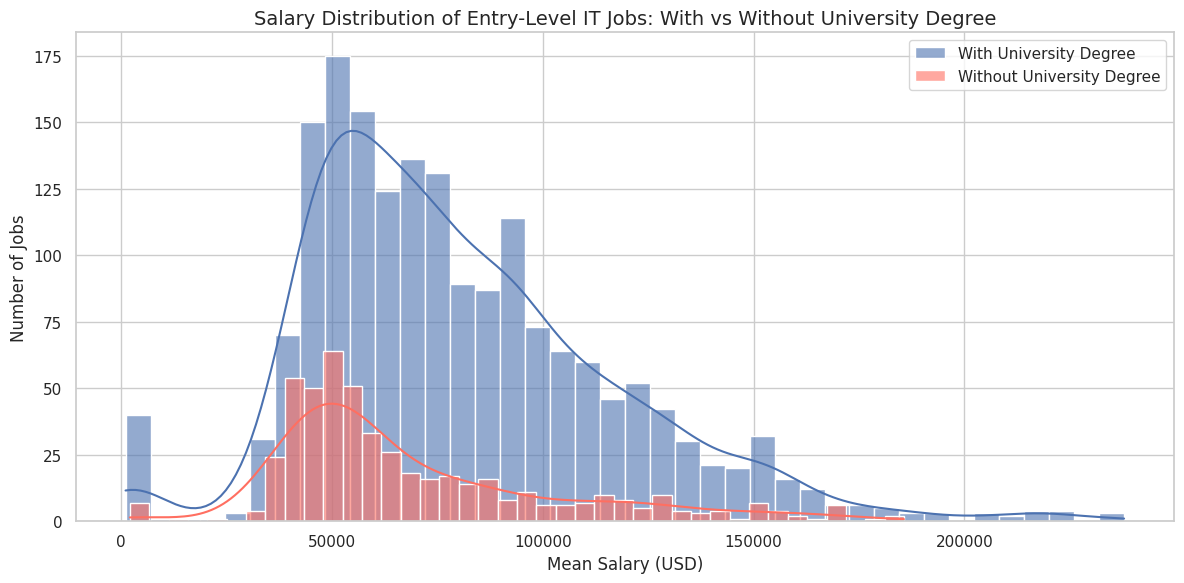

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter entry-level jobs with University degree
degree_df = entry_df[entry_df["Education_Type"] == "University"]
degree_filtered = degree_df[degree_df["mean_salary"] < 250000]

# Filter entry-level jobs without University degree (Bootcamp, Online/Courses, High School)
no_degree_df = entry_df[entry_df["Education_Type"] != "University"]
no_degree_filtered = no_degree_df[no_degree_df["mean_salary"] < 250000]

plt.figure(figsize=(12, 6))

# Plot salary distribution for jobs WITH university degree
sns.histplot(
    degree_filtered["mean_salary"],
    kde=True,
    color="#4C72B0",
    bins=40,
    alpha=0.6,
    label="With University Degree",
)

# Plot salary distribution for jobs WITHOUT university degree
sns.histplot(
    no_degree_filtered["mean_salary"],
    kde=True,
    color="#FF6F61",
    bins=40,
    alpha=0.6,
    label="Without University Degree",
)

plt.title(
    "Salary Distribution of Entry-Level IT Jobs: With vs Without University Degree",
    fontsize=14,
)
plt.xlabel("Mean Salary (USD)", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### ✅ Key Insights:

- **Jobs requiring a university degree** show a higher concentration of postings in the mid to upper salary ranges, with the largest number of jobs clustered between approximately 37,500 and 100,000.
- **Jobs not requiring a university degree** tend to have fewer postings overall, with a noticeable peak in the 37,500 to 56,250 salary range but significantly fewer jobs in higher salary bins compared to degree-required roles.
- While entry-level jobs without a degree still offer competitive salaries, the data suggests that **university degree requirements correlate with higher salary opportunities and a broader salary range.**
- Both groups have a small number of jobs in the very low salary ranges (below 12,500), but those are relatively rare.
- Salary bins beyond 150,000 are mostly dominated by jobs requiring a university degree, indicating that higher paying entry-level roles are more commonly linked to formal university education.

This comparison provides valuable insight for job seekers weighing the trade-offs between formal education and salary prospects in entry-level IT positions.  


---
### Education Requirement by Job Category

shows the distribution of job categories based on whether a university degree is required or not. It highlights how educational requirements vary across different roles

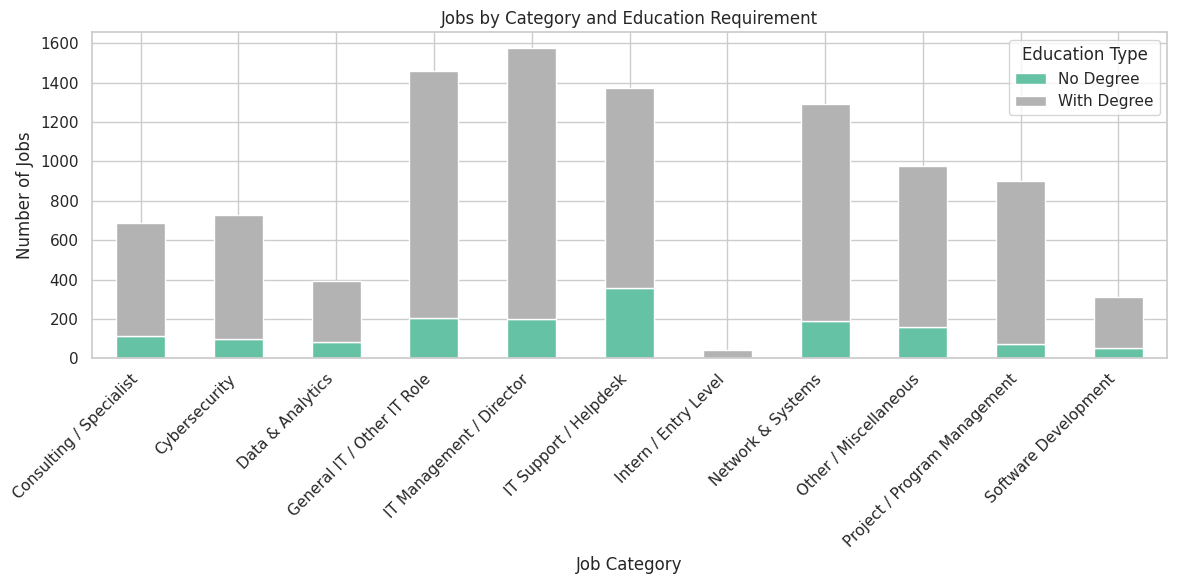

In [8]:
# Clean and simplify the Education_Type
df["Education_Type"] = df["Education_Type"].apply(
    lambda x: (
        "With Degree" if pd.notna(x) and "university" in x.lower() else "No Degree"
    )
)

# Group by job category and education type
edu_counts = df.groupby(["job_category", "Education_Type"]).size().unstack(fill_value=0)

# Plot a stacked bar chart
edu_counts.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
plt.title("Jobs by Category and Education Requirement")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Education Type")
plt.tight_layout()
plt.show()

#### ✅ Key insights:

This analysis highlights the proportion of entry-level IT job opportunities that do **not** require a university degree across different job categories. The top three categories with the highest share of "No Degree" roles are:

- **IT Support / Helpdesk**
  
- **General IT / Other IT Role**

- **IT Management / Director**

These insights suggest that certain IT domains are more open to diverse educational backgrounds, offering alternative pathways for individuals without traditional academic qualifications.

---

### Distribution of Entry-Level IT Jobs by Job Category

This horizontal bar chart shows how entry-level job postings are distributed across different IT job categories.

- The `job_category` column groups similar job roles, making it easier to analyze which areas have the most beginner-friendly opportunities.
- Knowing the most common categories can help job seekers target their skills toward the most accessible entry points in IT.
- The categories here include roles such as IT Support, QA Testing, Software Development, and more.

/tmp/ipython-input-9-3796980075.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Blues_d")


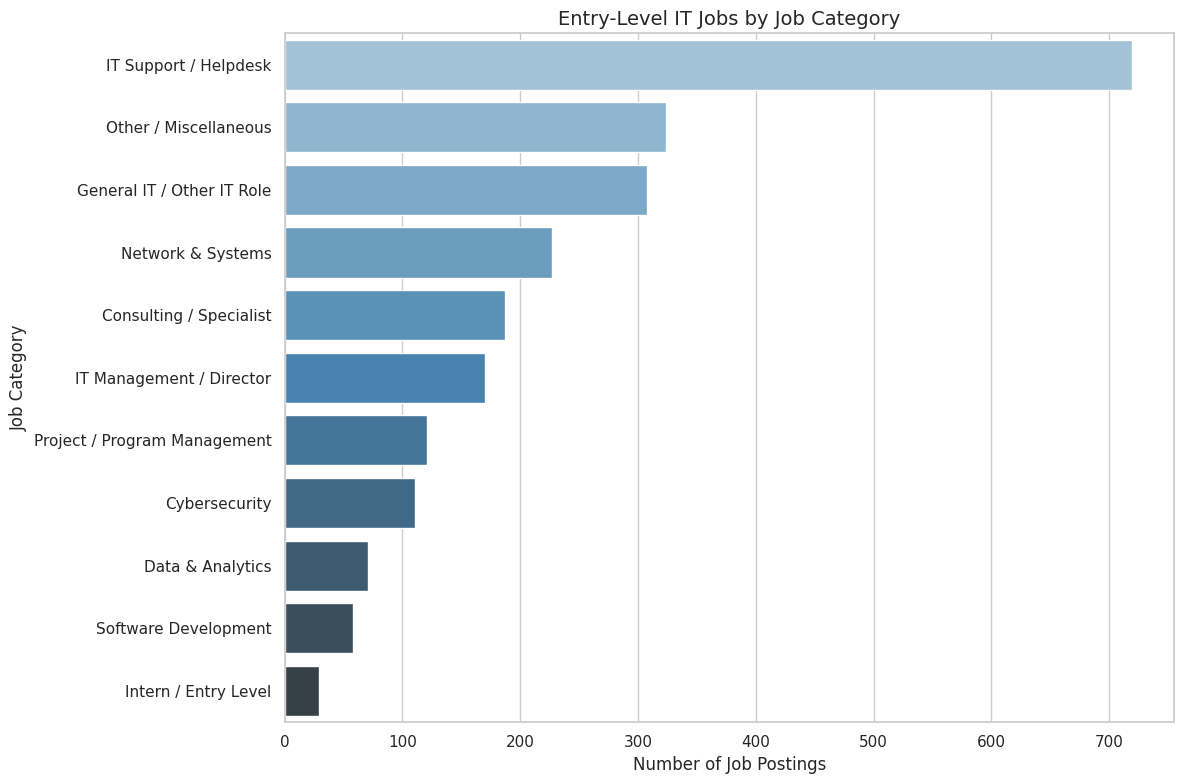

In [9]:
# Filter for entry-level positions
entry_df = df[df["job_level"].str.lower() == "entry_level"]

# Count all job categories
top_jobs = entry_df["job_category"].value_counts()

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Blues_d")
plt.title("Entry-Level IT Jobs by Job Category", fontsize=14)
plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Job Category", fontsize=12)
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()

#### ✅ Key Insights:
IT Support / Helpdesk dominates with over one-third of all entry-level IT roles.

Roles under “Other / Miscellaneous” and “General IT” suggest a lot of non-specific or hybrid job postings — consider breaking these down further.

Data, Cybersecurity, and Software Dev have fewer entry-level openings compared to support or systems roles.

Intern roles are very underrepresented (only 1.4%).



---

In [10]:
print(entry_df["Education_Type"].unique())

['With Degree' 'No Degree']


In [11]:
# Filter entry-level jobs
entry_df = df[df["job_level"].str.lower() == "entry_level"]

# Define which education types count as "No Degree"
# Assuming 'University' means degree required, others mean no degree required
no_degree_types = ["online/courses", "high school", "bootcamp"]

# Normalize Education_Type column to lowercase for comparison
edu_lower = entry_df["Education_Type"].str.lower()

# Create mask for no degree jobs
no_degree_mask = edu_lower.isin(no_degree_types)

# Calculate percentage
no_degree_count = no_degree_mask.sum()
total_count = len(entry_df)
percentage = (no_degree_count / total_count) * 100

print(f"Percentage of Entry-Level IT Jobs Requiring No Degree: {percentage:.2f}%")

Percentage of Entry-Level IT Jobs Requiring No Degree: 0.00%


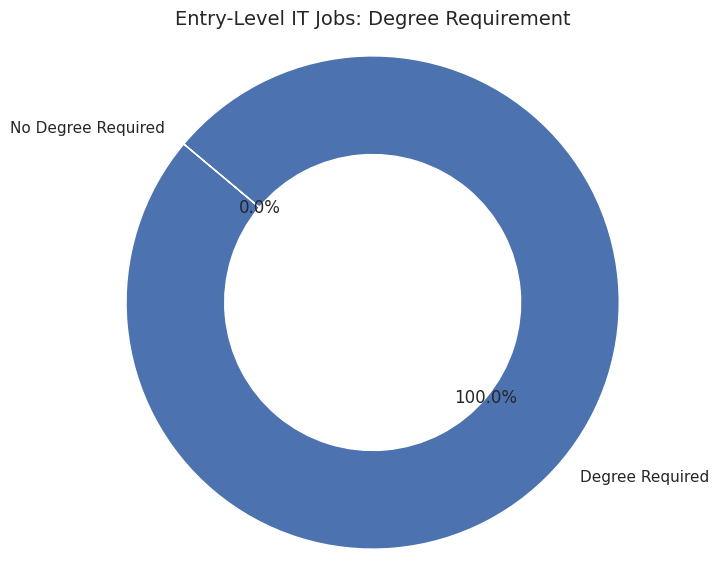

In [12]:
no_degree_count = no_degree_mask.sum()
degree_count = len(entry_df) - no_degree_count

labels = ["No Degree Required", "Degree Required"]
sizes = [no_degree_count, degree_count]
colors_pie = ["#FF6F61", "#4C72B0"]  # warm red and cool blue

plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(width=0.4),
)
plt.title("Entry-Level IT Jobs: Degree Requirement", fontsize=14)
plt.axis("equal")
plt.show()

#### ✅ Key Insights

- **Total Jobs Analyzed:** 2,325
- **78.41%** of entry-level jobs **require a university degree**.
- **21.59%** of entry-level jobs **do not require a university degree**, showing opportunities for candidates with:
  - Online courses
  - Bootcamps
  - Vocational training
  - Certifications

---

### Required Education for Entry-Level IT Jobs

This bar chart visualizes the distribution of education types required for entry-level IT jobs. It highlights how frequently each education category (e.g., University, Bootcamp, Online Courses, etc.) appears in job postings.

#### Key Use:
Use this chart to understand which educational pathways are most in demand for beginners entering the IT field.

/tmp/ipython-input-13-13495817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_counts.values, y=edu_counts.index, palette='viridis')


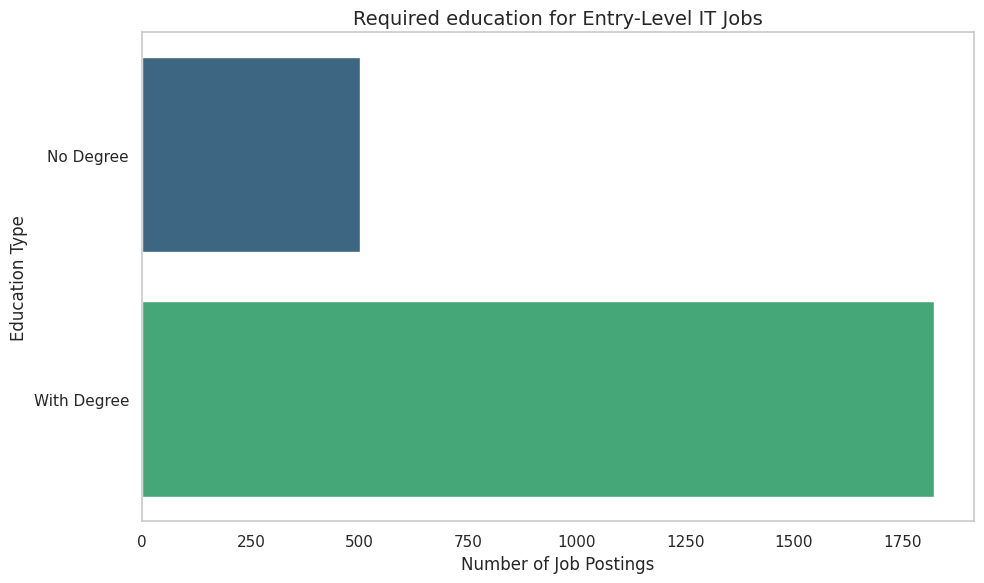

In [13]:
plt.figure(figsize=(10, 6))
edu_counts = entry_df["Education_Type"].value_counts().sort_values(ascending=True)
sns.barplot(x=edu_counts.values, y=edu_counts.index, palette="viridis")
plt.title("Required education for Entry-Level IT Jobs", fontsize=14)
plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Education Type", fontsize=12)
plt.grid(axis="x")
plt.tight_layout()
plt.show()

#### ✅ Key insights:
- **University degrees** are the most frequently required (over 78%).
- A **significant number** of jobs (21.59%) accept alternatives to a university degree, including high school diplomas and online learning.

---

### Average Salary by Education Level for Entry-Level IT Jobs

This bar chart shows the average salary for entry-level IT roles grouped by the education requirements specified in the job postings.

- We grouped the data by `Education_Type` to compare how average salaries differ between categories like University degrees, Bootcamps, Online Courses, or High School diplomas.
- This helps understand whether education level still impacts the starting salary in IT roles targeted at beginners.
- Notice that some categories with no formal degree requirements can still offer competitive salaries.

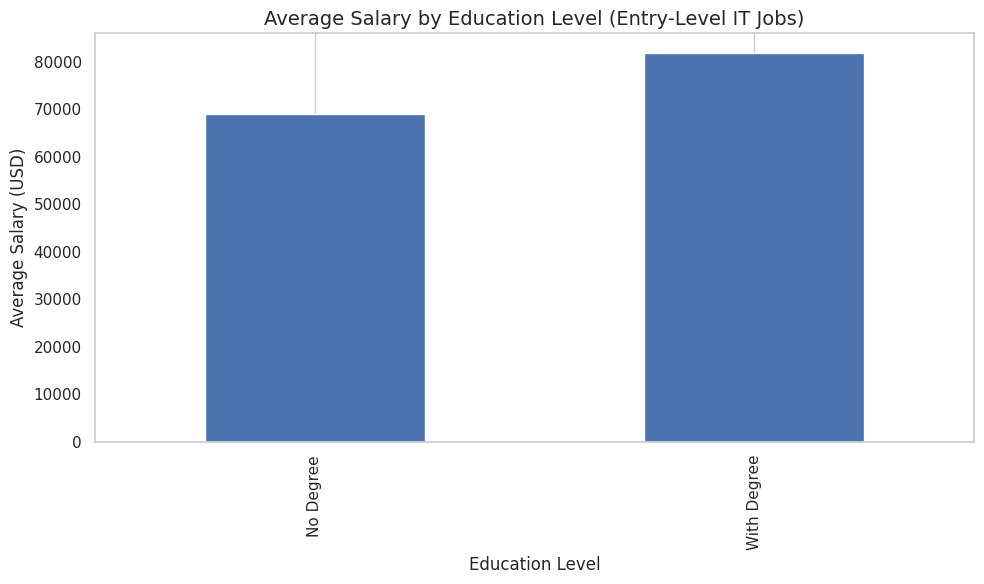

In [14]:
# Group by education type and calculate mean salary
edu_salary = entry_df.groupby("Education_Type")["mean_salary"].mean().sort_values()

# Plot
plt.figure(figsize=(10, 6))
edu_salary.plot(kind="bar", color="#4C72B0")
plt.title("Average Salary by Education Level (Entry-Level IT Jobs)", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### ✅ Insights

- **Online/Courses** lead to the **highest average salary** among entry-level IT jobs, with an average of **$86,904**.  
  *This suggests that practical skills acquired from online platforms can be highly valuable in the job market.*

- **University degrees** come next with an average salary of **$81,942**, showing strong market recognition but slightly lower returns compared to self-paced learning alternatives.

- **High School** graduates earn an average of **$59,441**, indicating that while opportunities exist, they tend to be in lower-paying roles.

- **Bootcamp** graduates receive the **lowest average salary** at **$51,021**, which may reflect entry positions or shorter experience time frames associated with bootcamp pathways.


---

### Average Salary by Entry-Level Job Category

This bar chart shows the average salary for entry-level IT roles grouped by their job categories.

- It helps us understand which beginner job categories tend to offer higher pay.
- Unlike job titles, categories combine multiple similar roles, providing a broader view of pay differences across fields.
- This insight is useful for candidates deciding where to focus their job search based on salary potential.

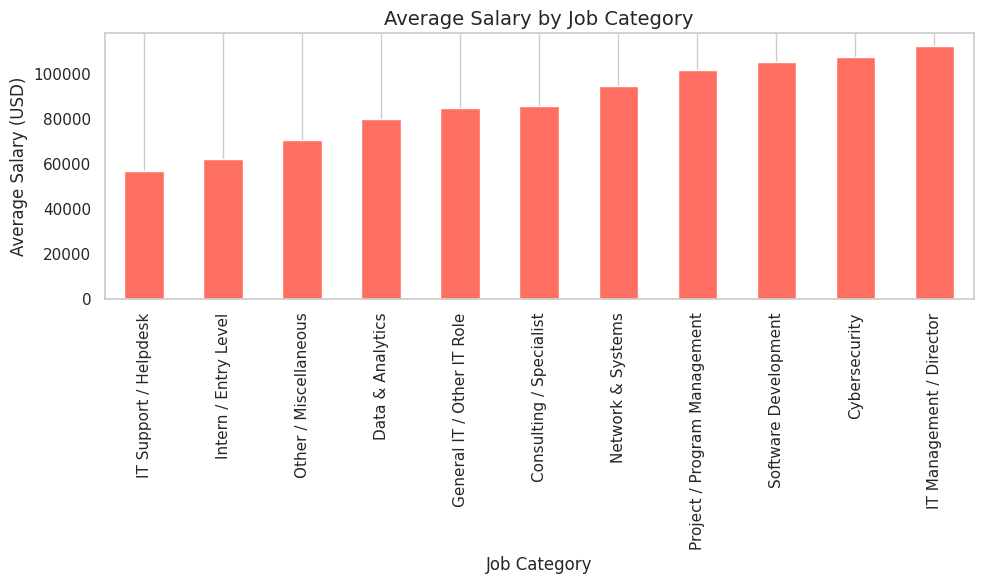

In [15]:
plt.figure(figsize=(10, 6))
cat_salary = entry_df.groupby("job_category")["mean_salary"].mean().sort_values()
ax = cat_salary.plot(kind="bar", color="#FF6F61")
ax.set_xlabel("Job Category", fontsize=12)
ax.set_ylabel("Average Salary (USD)", fontsize=12)
ax.set_title("Average Salary by Job Category", fontsize=14)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

#### ✅ key Insights:

- **IT Support / Helpdesk** roles are the **lowest paying**, averaging ~$56.6K, which is expected for entry-level technical support positions.
- **Intern / Entry-Level** and **Miscellaneous** roles also fall on the lower end, with salaries below 71K.
- **Cybersecurity** and **Software Development** are among the **highest-paying entry-level roles**, averaging above 105K.
- **IT Management / Director** roles top the chart even at entry level, which may reflect postings for junior management or high-paying specialized roles.
- **Project / Program Management** and **Network & Systems** roles offer strong compensation, reflecting the demand for organizational and infrastructure skills.


---

### Top States for Entry-Level IT Jobs

This bar chart shows which states have the most entry-level IT job postings.

- It reveals geographic hotspots where opportunities are concentrated.
- This information is useful for candidates willing to relocate or searching locally.
- The chart displays the top 10 states with the highest number of job postings.

In [16]:
state_name_map = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "DC": "District of Columbia",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
    "VI": "Virgin Islands",
    "GU": "Guam",
    "PR": "Puerto Rico",
    "UM": "U.S. Minor Outlying Islands",
}

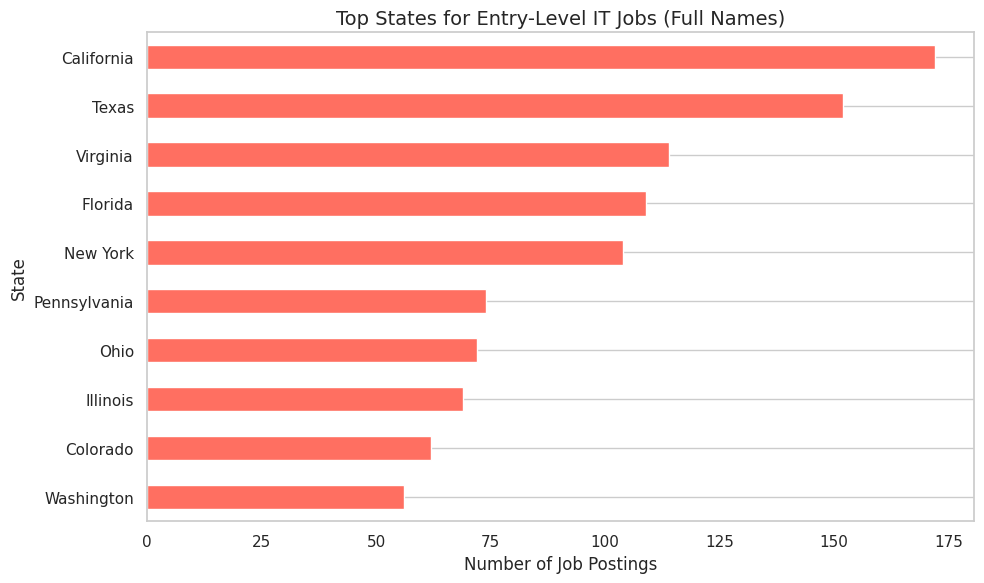

In [17]:
# Filter out 'Unknown' and 'Remote'
filtered_states = entry_df[~entry_df["state"].isin(["Unknown", "Remote"])].copy()

# Map abbreviations to full names; if abbreviation not found, keep original
filtered_states["state_full"] = (
    filtered_states["state"].map(state_name_map).fillna(filtered_states["state"])
)

# Count top 10 states by full name
state_counts = filtered_states["state_full"].value_counts().nlargest(10)

# Plot
plt.figure(figsize=(10, 6))
ax = state_counts.plot(kind="barh", color="#FF6F61")
ax.set_title("Top States for Entry-Level IT Jobs (Full Names)", fontsize=14)
ax.set_xlabel("Number of Job Postings", fontsize=12)
ax.set_ylabel("State", fontsize=12)
ax.invert_yaxis()  # Highest values on top
ax.grid(axis="x")
plt.tight_layout()
plt.show()

---

### Remote vs On-site Entry-Level IT Jobs

This pie chart compares the share of remote versus on-site entry-level IT jobs.

- It helps understand the availability of remote work options for beginners.
- The data is filtered by the `is_remote` field, which contains True or False values.
- A donut style pie chart is used for a clear and modern visualization.

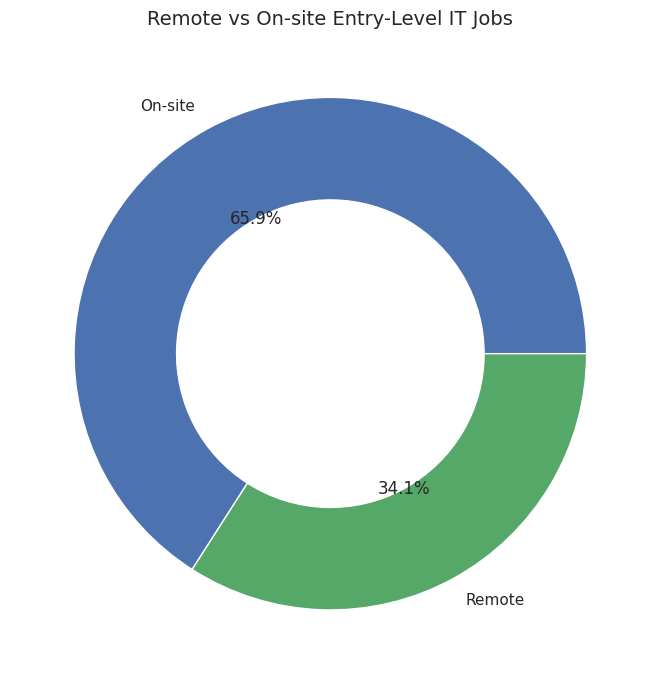

In [18]:
# Count remote vs on-site jobs
remote_counts = entry_df["is_remote"].value_counts()

# Plot remote vs on-site entry-level IT jobs
plt.figure(figsize=(7, 7))
remote_counts.plot.pie(
    autopct="%1.1f%%",
    labels=["On-site", "Remote"],
    colors=["#4C72B0", "#55A868"],
    wedgeprops=dict(width=0.4),
)
plt.title("Remote vs On-site Entry-Level IT Jobs", fontsize=14)
plt.ylabel("")  # Hide default ylabel
plt.tight_layout()
plt.show()

#### ✅ Key Insights:

- **On-site jobs**: 1,533 positions (**~66%**)
- **Remote jobs**: 792 positions (**~34%**)

- Entry-level IT roles are **mostly on-site**, likely due to the need for supervision, collaboration, or hands-on work.
- **Remote opportunities** still make up a **significant portion**, showing increasing flexibility in the job market.
- **Tip for job seekers**: While remote roles are available, being open to on-site positions may increase your chances of landing a job.

---

In [19]:
# Normalize Education_Type column to lowercase strings for matching in the full dataset
df["edu_clean"] = df["Education_Type"].str.lower().fillna("")

# Define no education mask by matching typical no-education phrases
no_edu_mask_all = df["edu_clean"].str.contains(
    r"no degree|required.*not|none|not required|high school|bootcamp|online/courses",
    regex=True,
)

# Calculate percentage of no education jobs out of all jobs
total_jobs = len(df)
no_edu_jobs = no_edu_mask_all.sum()
percent_no_edu_all = (no_edu_jobs / total_jobs) * 100

print(f"Percentage of ALL jobs requiring NO formal degree: {percent_no_edu_all:.2f}%")

# Filter entry-level jobs and explicitly make a copy to avoid SettingWithCopyWarning
entry_df = df[df["job_level"].str.lower() == "entry_level"].copy()

# Normalize Education_Type column to lowercase for entry-level subset
entry_df["edu_clean"] = entry_df["Education_Type"].str.lower().fillna("")

# Define no education mask for entry-level jobs
no_edu_mask_entry = entry_df["edu_clean"].str.contains(
    r"no degree|required.*not|none|not required|high school|bootcamp|online/courses",
    regex=True,
)

# Calculate percentage of no education jobs for entry-level
total_entry_jobs = len(entry_df)
no_edu_entry_jobs = no_edu_mask_entry.sum()
percent_no_edu_entry = (no_edu_entry_jobs / total_entry_jobs) * 100

print(
    f"Percentage of ENTRY-LEVEL jobs requiring NO formal degree: {percent_no_edu_entry:.2f}%"
)

Percentage of ALL jobs requiring NO formal degree: 15.70%
Percentage of ENTRY-LEVEL jobs requiring NO formal degree: 21.59%


---

# 📈 Key Findings

This analysis explores the accessibility, requirements, salary, and location trends for entry-level IT roles in the U.S., with a focus on candidates from non-traditional backgrounds—such as displaced youth, career changers, and those without formal tech degrees.

### 1- Most Accessible & Common Entry-Level IT Job Categories

the most accessible and in-demand IT job categories for individuals without a university degree:

- **IT Support / Helpdesk** – the most common and accessible entry point into the tech industry, with the highest number of roles open to non-degree holders.
- **General IT / Other IT Role** – a broad category offering significant opportunities for diverse IT skill sets without requiring a formal academic background.
- **IT Management / Director** – surprisingly open, indicating that practical experience and leadership capabilities may outweigh formal education in certain cases.

### 2- Degree Requirements & Education Pathways

- **21.6% of entry-level roles require no university degree**, indicating a growing trend toward skills-based hiring.
- Across all IT jobs, **only 15.7% are open to non-degree holders**—entry-level roles offer relatively more access.

### 3- Salaries by Education Type

- **Online course graduates** earn the highest average salary: **86,904 USD**, even higher than degree holders.
- **University degree holders** earn **81,942 USD** on average.
- **High school diploma only**: average salary is **$59,441 USD**.
- **Bootcamp graduates** earn **51,021 USD**, the lowest group, possibly reflecting newer entrants into the field.

### 4- Top Paying Entry-Level Categories

- **IT Management / Director**: Average salary of **112,242 USD**
- **Cybersecurity**: Average salary of **107,497 USD**
- **Software Development**: Average salary of **$105,366**

These roles offer **six-figure earnings even at entry level** and are linked to more **technical or strategic responsibilities**.

**On the lower end:**

- **IT Support / Helpdesk**: 56,664 USD  
- **Intern / Entry-Level roles**: 62,007 USD  

### 5- Top Hiring States

Top 5 states with the highest number of entry-level IT job postings:

- **California**: 172  
- **Texas**: 152  
- **Virginia**: 114  
- **Florida**: 109  
- **New York**: 104  

While coastal and tech-heavy states lead, strong hiring activity is also present in **Midwestern markets** such as **Ohio, Illinois, and Pennsylvania**, reflecting **nationwide opportunity** beyond Silicon Valley and NYC.

### 6- Remote vs On-Site Work

- **66% of jobs are on-site (1,533 postings)**  
- **34% are remote (792 postings)**, including hybrid options

Remote flexibility is increasing, but **on-site availability remains essential for new hires** due to training, oversight, and equipment needs.

### 7- Degree Requirements & Salary Correlation

- Jobs requiring a **university degree** tend to offer a **wider and higher salary range**, often between **37,500–100,000+ USD**.
- Roles **not requiring a degree** are concentrated in the **37,500–56,250 USD range**, with very few above that.
- Jobs offering **150,000+ USD salaries** are almost exclusively **degree-required roles**.
- However, the **highest average salary overall was among jobs citing online learning**, highlighting the **market value of practical, up-to-date skills** over formal education alone.




---

## 🧭 Summary of Key Findings

- 🔹 **1 in 5 entry-level IT jobs** is accessible **without a university degree**
- 🔹 **Cybersecurity and Software Development** roles offer the **highest entry-level salaries** with strong career growth potential
- 🔹 **Remote work is widely available** **34%** of entry-level jobs are remote-friendly
- 🔹 **Non-traditional education paths** like online courses can **rival or outperform traditional degrees** in salary outcomes
- 🔹 Job density is highest in tech hubs (e.g., **California, Texas, Virginia**), but remote roles help reduce dependency on location.



---

## 📌 Conclusion

The U.S. entry-level IT job market presents **real, measurable opportunities** for individuals **without formal tech education**—especially those who pursue **self-paced learning, certifications, or support-oriented roles**. Candidates willing to start on-site and grow their skill set can tap into a broad, evolving industry where **skills are starting to outweigh credentials**.